[Part 1: 데이터 전처리 및 탐색 (EDA)]

Cell 1: 환경 설정 및 데이터 로드

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler

# 시각화 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_csv('telco-customer.csv')
print(f"데이터 로드 완료: {df.shape}")

데이터 로드 완료: (7043, 21)


Cell 2: 데이터 클리닝 및 컬럼명 변경

In [7]:
# 1. TotalCharges 수치형 변환 및 결측치 처리
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# 2. 분석용 컬럼명 변경 (Next Anchor 프로젝트 표준)
df = df.rename(columns={
    'tenure': 'Subscription_Months',
    'MonthlyCharges': 'Monthly_Fee',
    'TotalCharges': 'Cumulative_Revenue',
    'Contract': 'Billing_Cycle'
})

# 3. 중복 표현 정리
df = df.replace(['No internet service', 'No phone service'], 'No')
print("기본 클리닝 및 컬럼명 변경 완료")

기본 클리닝 및 컬럼명 변경 완료


Cell 3: 파생 변수 생성

In [8]:
six_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# 6가지 서비스 중 'Yes'인 항목의 합계 계산
df['Active_Features_Count'] = df[six_services].apply(lambda x: x.isin(['Yes', 1])).sum(axis=1)
print("Active_Features_Count(0~6점) 생성 완료")

Active_Features_Count(0~6점) 생성 완료


Cell 4: 인코딩 및 데이터 프레임 확정

In [9]:
# 1. 이진 및 성별 매핑
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'PaperlessBilling', 'Churn'] + six_services
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# 2. 원핫인코딩 및 불필요 컬럼 제거
df_temp = pd.get_dummies(df.drop(columns=['customerID'], errors='ignore'))
df_final = df_temp.fillna(0).astype(int)
print(f"인코딩 완료. 최종 컬럼 수: {len(df_final.columns)}")

인코딩 완료. 최종 컬럼 수: 28


Cell 5: 수치형 데이터 스케일링

In [10]:
scaler = MinMaxScaler()
target_cols = ['Subscription_Months', 'Monthly_Fee', 'Cumulative_Revenue', 'Active_Features_Count']
df_final[target_cols] = scaler.fit_transform(df_final[target_cols])
print("Min-Max 스케일링 완료")

Min-Max 스케일링 완료


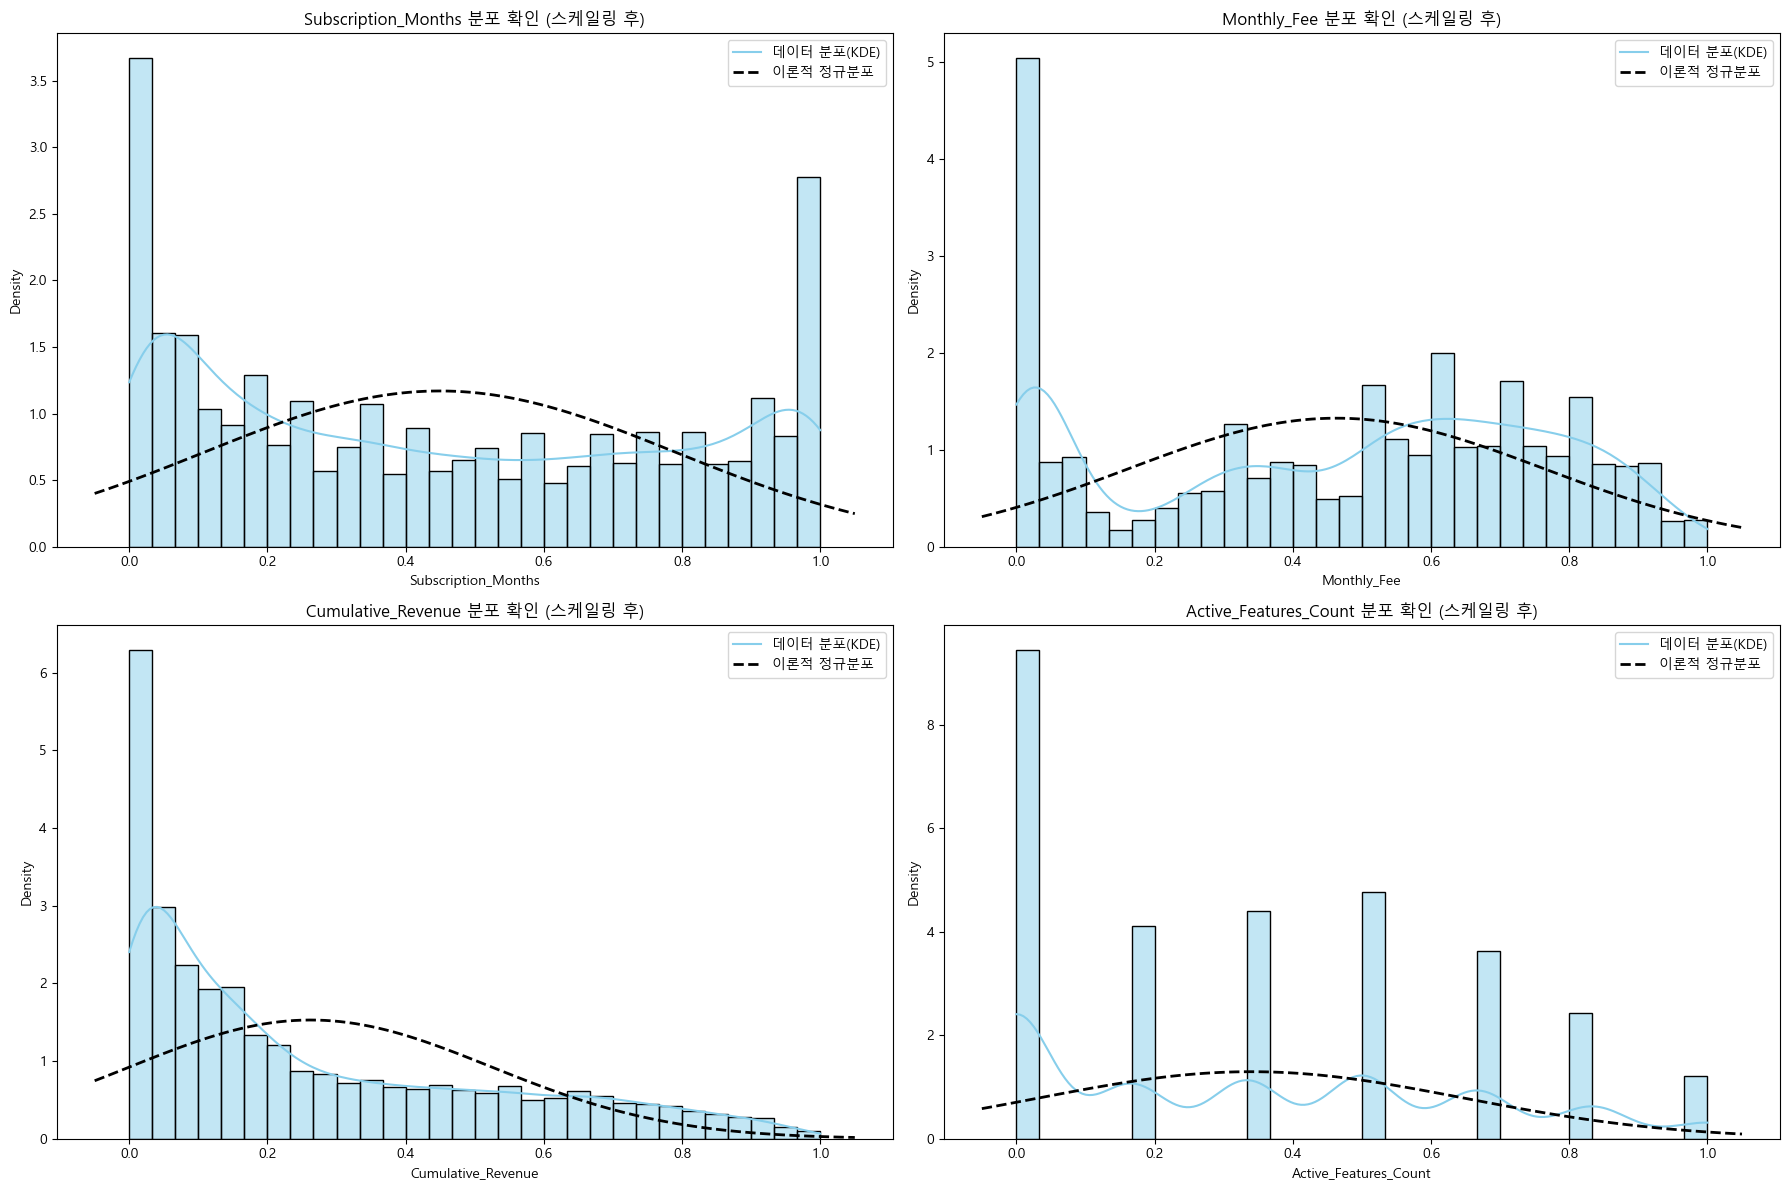

In [11]:
plt.figure(figsize=(18, 12))

# 4개 지표의 분포 확인
for i, col in enumerate(target_cols):
    plt.subplot(2, 2, i+1)
    
    # 히스토그램 및 밀도 곡선
    sns.histplot(df_final[col], kde=True, stat="density", color='skyblue', bins=30)
    
    # 정규분포 곡선(검정 점선) 추가
    mu, std = norm.fit(df_final[col])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2, linestyle='--')
    
    plt.title(f'{col} 분포 확인 (스케일링 후)')
    plt.legend(['데이터 분포(KDE)', '이론적 정규분포'])

plt.tight_layout()
plt.show()

서비스 이용 개수별 이탈률 요약


,Active_Features_Count,Monthly_Fee,Subscription_Months,Churn
0,0,32.792902,24.131140,0.214060
1,1,65.574275,16.868530,0.457557
2,2,72.417473,26.042594,0.358180
3,3,80.110510,36.671735,0.273703
4,4,87.771538,47.215962,0.223005
5,5,92.176007,55.264448,0.124343
6,6,99.365317,65.010563,0.052817


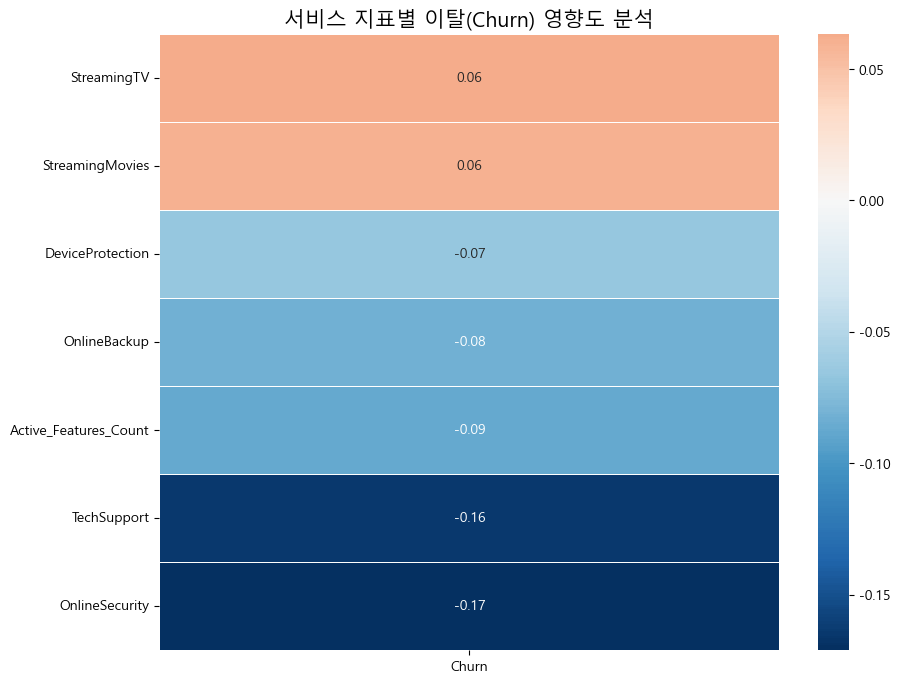

In [12]:
# 1. 서비스 이용 개수별 요약 표 생성
# 스케일링 전의 원본 점수를 보기 위해 df를 기준으로 그룹화합니다.
comparison = df.groupby('Active_Features_Count').agg({
    'Monthly_Fee': 'mean',
    'Subscription_Months': 'mean',
    'Churn': 'mean'
}).reset_index()

print("서비스 이용 개수별 이탈률 요약")
display(comparison)

# 2. 6대 서비스 + 활성 서비스 수 히트맵
plt.figure(figsize=(10, 8))

# 히트맵에 포함할 컬럼 정의
heatmap_features = six_services + ['Active_Features_Count']

# Churn과의 상관관계만 추출하여 시각화
churn_corr = df_final[heatmap_features + ['Churn']].corr()[['Churn']].drop('Churn')

sns.heatmap(churn_corr.sort_values(by='Churn', ascending=False), 
            annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5)

plt.title('서비스 지표별 이탈(Churn) 영향도 분석', fontsize=15)
plt.show()

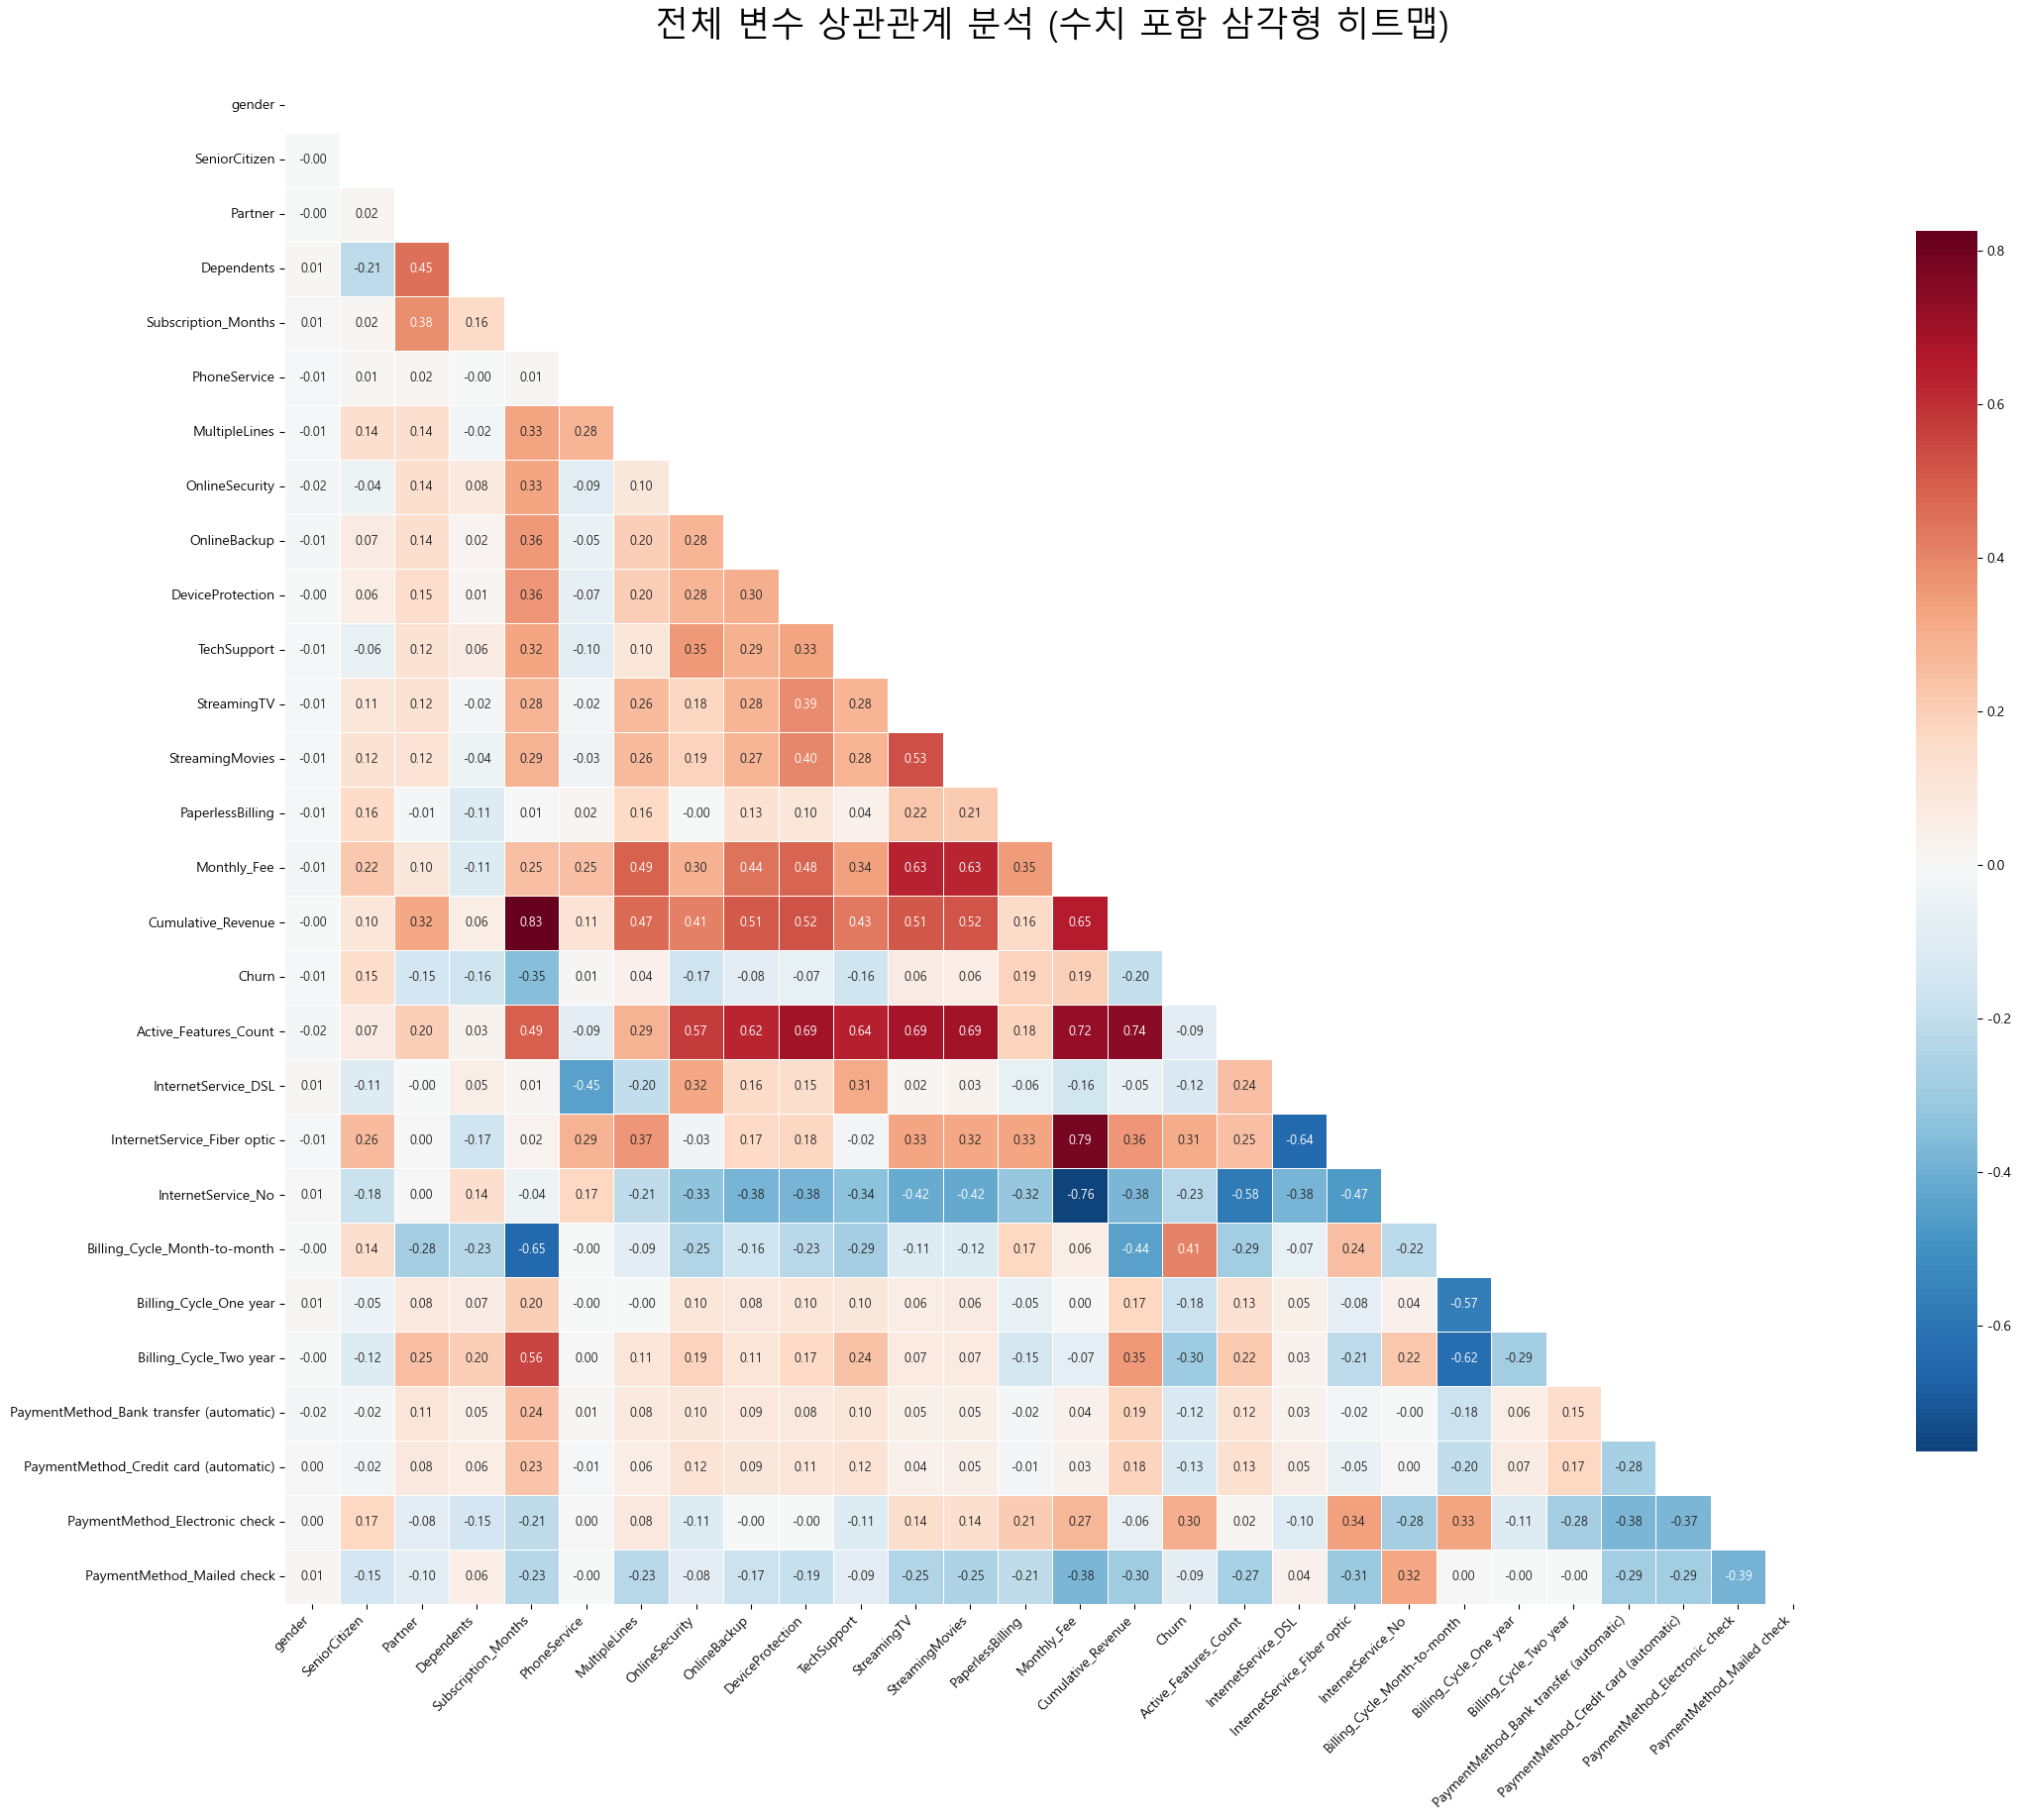

In [13]:
# 1. 상관관계 계산
corr = df_final.corr()

# 2. 상삼각 행렬 마스크 생성 (윗부분 가리기)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. 히트맵 시각화
# 변수가 많으므로 숫자가 잘 보이도록 크기를 대폭 키웁니다.
plt.figure(figsize=(25, 20))

sns.heatmap(corr, 
            mask=mask, 
            annot=True,          # 수치 표시 활성화
            fmt=".2f",           # 소수점 둘째자리까지 표시
            cmap='RdBu_r', 
            center=0, 
            linewidths=0.5,      # 칸 사이 구분선 추가
            annot_kws={"size": 9}, # 수치 글자 크기 조절 (겹침 방지)
            cbar_kws={"shrink": .8})

plt.title('전체 변수 상관관계 분석 (수치 포함 삼각형 히트맵)', fontsize=25, pad=30)
plt.xticks(rotation=45, ha='right') # X축 라벨 각도 조절
plt.show()

Cell 9: 전처리 결과 저장

In [14]:
df_final.to_csv('preprocessed_telco_data_final.csv', index=False, encoding='utf-8-sig')
print('Preprocessed data saved (scaler is included in model bundle)')



Preprocessed data saved (scaler is included in model bundle)


[Part 2: 모델링 및 성능 최적화]

Cell 10: 데이터 분할 (8:2)

In [15]:
from sklearn.model_selection import train_test_split

df_final = pd.read_csv('preprocessed_telco_data_final.csv')
X = df_final.drop('Churn', axis=1) # 데이터 누수 방지
y = df_final['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"데이터 분할 및 클래스 가중치({scale_weight:.2f}) 설정 완료")

데이터 분할 및 클래스 가중치(2.77) 설정 완료


Cell 11 : 비교용 random / Grid Search 최적 파라미터 탐색

In [16]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint
from xgboost import XGBClassifier

# 1. Randomized Search (넓은 범위 탐색)
# 전체 파라미터 공간에서 무작위로 20개를 골라 효율적으로 범위를 좁힙니다.
param_dist = {
    'max_depth': randint(3, 7),
    'learning_rate': uniform(0.01, 0.1),
    'n_estimators': [500, 1000],
    'subsample': uniform(0.6, 0.3), # 0.6 ~ 0.9
    'colsample_bytree': uniform(0.6, 0.3)
}

random_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_weight, random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=20, # 20번 랜덤 샘플링
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)
print(f" Random Search Best Params: {random_search.best_params_}")


# 2. Grid Search (확정된 범위 주변 정밀 탐색)
# Randomized Search에서 나온 결과 근처를 촘촘하게 검증합니다.
param_grid = {
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.02, 0.03],
    'min_child_weight': [5, 7, 10]
}

grid_search = GridSearchCV(
    XGBClassifier(n_estimators=1000, scale_pos_weight=scale_weight, random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print(f" Grid Search Best Params: {grid_search.best_params_}")

 Random Search Best Params: {'colsample_bytree': np.float64(0.6265477506155759), 'learning_rate': np.float64(0.029598286241914525), 'max_depth': 3, 'n_estimators': 1000, 'subsample': np.float64(0.6975990992289793)}
 Grid Search Best Params: {'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 10}


Cell 12: Optuna 최적 파라미터 탐색

In [17]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

def objective(trial):
    param = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.02),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 20),
        'gamma': trial.suggest_float('gamma', 1.0, 5.0),
        'subsample': trial.suggest_float('subsample', 0.6, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 1.0, 15.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 15.0),
        'scale_pos_weight': scale_weight,
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    model = XGBClassifier(**param, early_stopping_rounds=50)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    return f1_score(y_test, model.predict(X_test))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
print(f"최적 파라미터: {study.best_params}")

[I 2026-03-24 17:58:40,056] A new study created in memory with name: no-name-4d9c7f3d-251f-468e-9a11-ed5dc39674fb
[I 2026-03-24 17:58:40,945] Trial 0 finished with value: 0.6288117770767613 and parameters: {'learning_rate': 0.017354576844262448, 'max_depth': 5, 'min_child_weight': 6, 'gamma': 3.5670794134277464, 'subsample': 0.799178400747155, 'colsample_bytree': 0.7488939941777135, 'reg_alpha': 7.80374354282251, 'reg_lambda': 10.11526825682132}. Best is trial 0 with value: 0.6288117770767613.
[I 2026-03-24 17:58:41,952] Trial 1 finished with value: 0.6243496357960457 and parameters: {'learning_rate': 0.013577954354192383, 'max_depth': 3, 'min_child_weight': 16, 'gamma': 3.357838238151254, 'subsample': 0.7747205622834317, 'colsample_bytree': 0.6911449231777624, 'reg_alpha': 1.3825367380852154, 'reg_lambda': 3.7888435212527285}. Best is trial 0 with value: 0.6288117770767613.
[I 2026-03-24 17:58:42,720] Trial 2 finished with value: 0.6274921301154249 and parameters: {'learning_rate': 0.

최적 파라미터: {'learning_rate': 0.018612408824673868, 'max_depth': 6, 'min_child_weight': 9, 'gamma': 3.068267694374302, 'subsample': 0.7410789251573389, 'colsample_bytree': 0.7985021039269422, 'reg_alpha': 1.984309902965666, 'reg_lambda': 13.260820948289465}


Cell 13: 최종 모델 학습 및 학습 곡선 시각화

최종 파라미터: {'learning_rate': 0.018, 'max_depth': 6, 'min_child_weight': 9, 'gamma': 3.068, 'subsample': 0.741, 'colsample_bytree': 0.798, 'reg_alpha': 1.984, 'reg_lambda': 13.26, 'n_estimators': 2000, 'scale_pos_weight': np.float64(2.768561872909699), 'random_state': 42, 'eval_metric': ['error', 'logloss'], 'early_stopping_rounds': 50}
[0]	validation_0-error:0.23074	validation_0-logloss:0.68731	validation_1-error:0.24840	validation_1-logloss:0.68754
[100]	validation_0-error:0.23376	validation_0-logloss:0.48735	validation_1-error:0.24627	validation_1-logloss:0.50439
[200]	validation_0-error:0.22417	validation_0-logloss:0.45905	validation_1-error:0.25053	validation_1-logloss:0.48566
[300]	validation_0-error:0.22258	validation_0-logloss:0.44916	validation_1-error:0.24485	validation_1-logloss:0.48142
[400]	validation_0-error:0.22151	validation_0-logloss:0.44533	validation_1-error:0.24627	validation_1-logloss:0.48002
[500]	validation_0-error:0.22009	validation_0-logloss:0.44283	validation_1-e

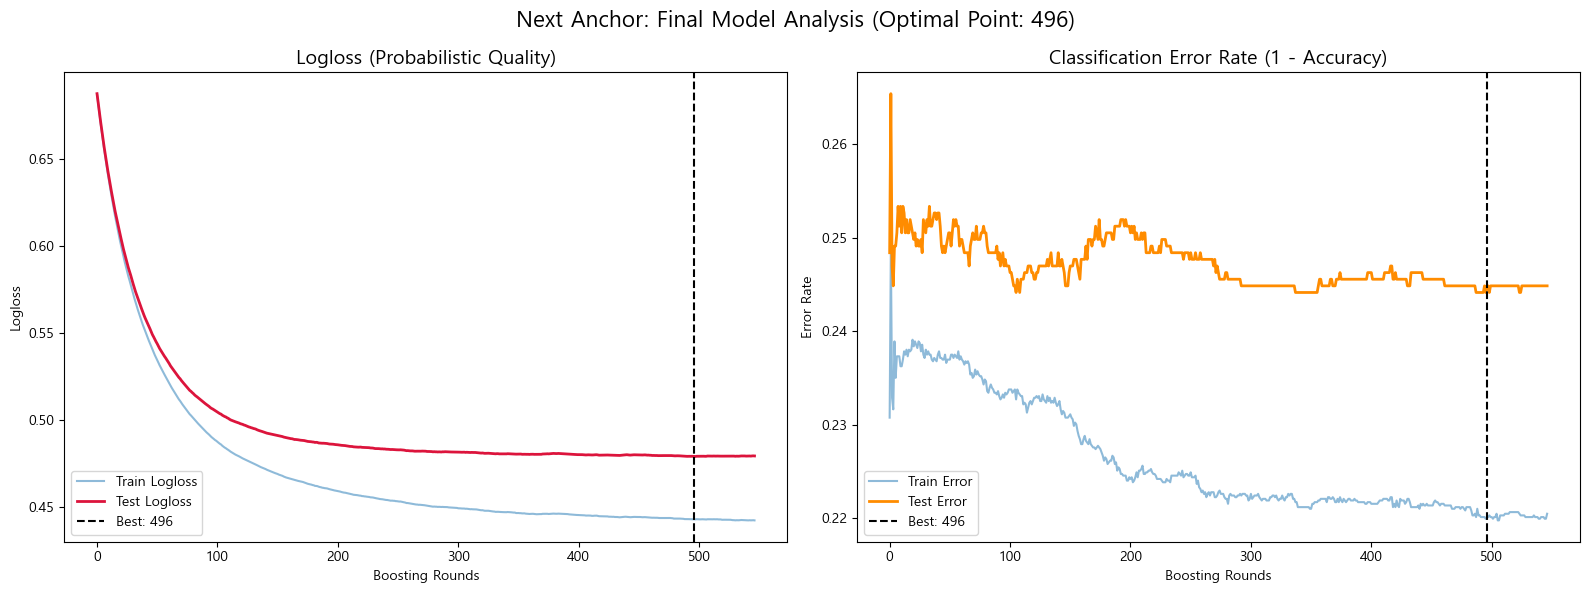

최종 모델 학습 완료. 최적 반복 횟수(Best Iteration): 496


In [18]:
final_best_params = {
    'learning_rate': 0.018,
    'max_depth': 6,
    'min_child_weight': 9,
    'gamma': 3.068,
    'subsample': 0.741,
    'colsample_bytree': 0.798,
    'reg_alpha': 1.984,
    'reg_lambda': 13.26,
    'n_estimators': 2000,
    'scale_pos_weight': scale_weight,
    'random_state': 42,
    'eval_metric': ['error', 'logloss'],
    'early_stopping_rounds': 50
}

print(f"최종 파라미터: {final_best_params}")

# 1. 최적 하이퍼파라미터로 최종 모델 학습
model_final = XGBClassifier(**final_best_params)
model_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

# 2. 학습 과정 시각화
results = model_final.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: Logloss (확률 예측 성능 확인)
ax[0].plot(x_axis, results['validation_0']['logloss'], label='Train Logloss', alpha=0.5)
ax[0].plot(x_axis, results['validation_1']['logloss'], label='Test Logloss', color='crimson', lw=2)
ax[0].axvline(model_final.best_iteration, color='black', linestyle='--', label=f'Best: {model_final.best_iteration}')
ax[0].set_title('Logloss (Probabilistic Quality)', fontsize=14)
ax[0].set_xlabel('Boosting Rounds')
ax[0].set_ylabel('Logloss')
ax[0].legend()

# 오른쪽: Error Rate (분류 오류율 확인)
ax[1].plot(x_axis, results['validation_0']['error'], label='Train Error', alpha=0.5)
ax[1].plot(x_axis, results['validation_1']['error'], label='Test Error', color='darkorange', lw=2)
ax[1].axvline(model_final.best_iteration, color='black', linestyle='--', label=f'Best: {model_final.best_iteration}')
ax[1].set_title('Classification Error Rate (1 - Accuracy)', fontsize=14)
ax[1].set_xlabel('Boosting Rounds')
ax[1].set_ylabel('Error Rate')
ax[1].legend()

plt.suptitle(f"Next Anchor: Final Model Analysis (Optimal Point: {model_final.best_iteration})", fontsize=16)
plt.tight_layout()
plt.show()

print(f"최종 모델 학습 완료. 최적 반복 횟수(Best Iteration): {model_final.best_iteration}")

확률 보정 곡선

Cell 15: 임계값 최적화

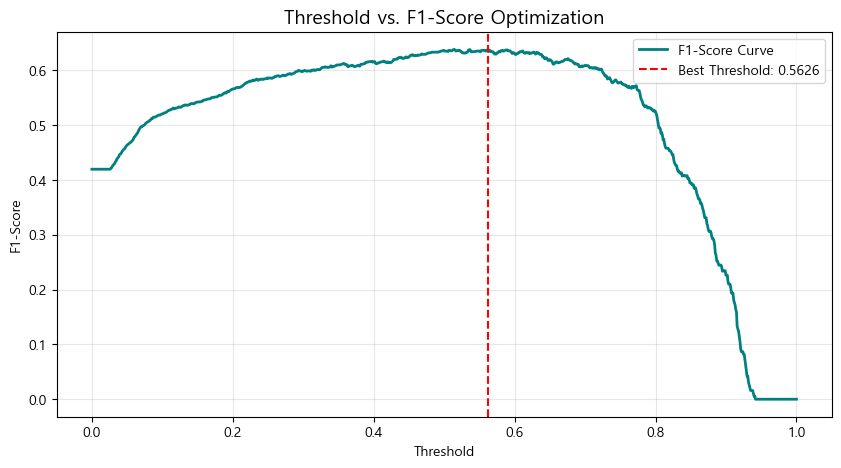

In [19]:
from sklearn.metrics import f1_score, precision_recall_curve

# 1. 새로운 모델로 예측 확률 추출
y_probs = model_final.predict_proba(X_test)[:, 1]

# 2. 임계값 후보군 생성 및 F1-Score 계산
thresholds = np.linspace(0, 1, 1000) # 0.001 단위로 정밀하게 탐색
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]

# 3. 최적 임계값 및 해당 점수 찾기
best_idx = np.argmax(f1_scores)
new_best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# 4. 임계값 선택 시각화 (선택 사항)
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, label='F1-Score Curve', color='teal', lw=2)
plt.axvline(new_best_threshold, color='red', linestyle='--', 
            label=f'Best Threshold: {new_best_threshold:.4f}')
plt.title('Threshold vs. F1-Score Optimization', fontsize=14)
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

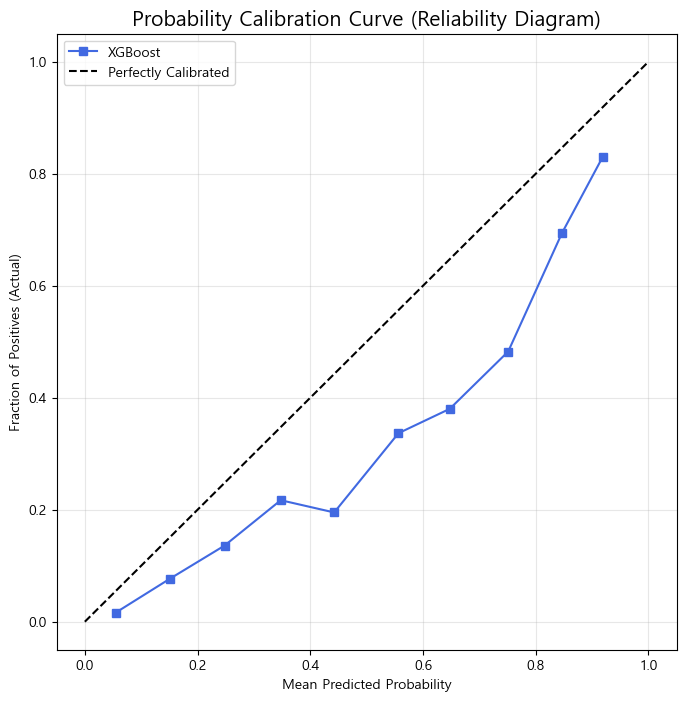

In [20]:
from sklearn.calibration import calibration_curve

# 1. 보정 곡선 데이터 생성
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

# 2. 시각화
plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='s', label='XGBoost', color='royalblue')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated', color='black')

plt.title('Probability Calibration Curve (Reliability Diagram)', fontsize=15)
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Cell 15: 최종 성과 보고서 및 혼동 행렬

프로젝트 최종 성과
              precision    recall  f1-score   support

       유지(0)       0.90      0.77      0.83      1035
       이탈(1)       0.55      0.76      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409

ROC-AUC Score: 0.8487


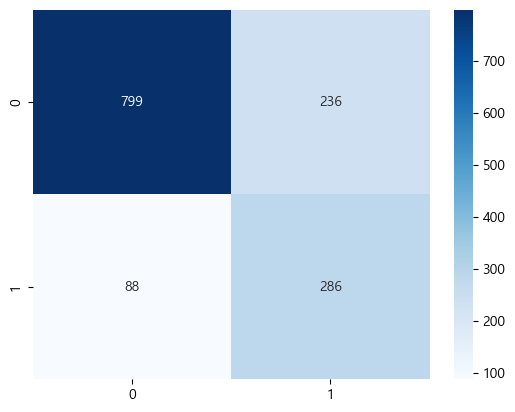

In [21]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

FINAL_THRESHOLD = new_best_threshold
y_pred_final = (y_probs >= FINAL_THRESHOLD).astype(int)

print("프로젝트 최종 성과")
print(classification_report(y_test, y_pred_final, target_names=['유지(0)', '이탈(1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

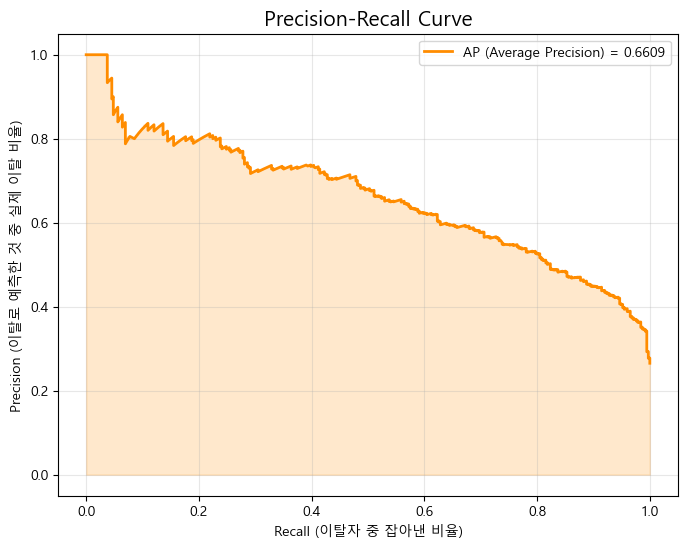

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. PR 곡선 데이터 생성
precision, recall, _ = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

# 2. 시각화
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'AP (Average Precision) = {ap_score:.4f}')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='darkorange')

plt.title('Precision-Recall Curve', fontsize=15)
plt.xlabel('Recall (이탈자 중 잡아낸 비율)')
plt.ylabel('Precision (이탈로 예측한 것 중 실제 이탈 비율)')
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
from pathlib import Path
from datetime import datetime
import joblib
import xgboost as xgb

required_vars = ['model_final', 'X_train']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing required variables: {missing}. Run training notebook first to create model_final and X_train."
    )

threshold = globals().get('FINAL_THRESHOLD', 0.5)
scaler_obj = globals().get('scaler', None)

print('Ready to save artifacts')
print(f'- threshold: {threshold}')
print(f'- scaler included: {scaler_obj is not None}')


Ready to save artifacts
- threshold: 0.5625625625625625
- scaler included: True


In [25]:
save_dir = Path('artifacts')
save_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    'model': model_final,
    'feature_names': list(X_train.columns),
    'threshold': float(threshold),
    'scaler': scaler_obj,
    'created_at': datetime.now().isoformat(timespec='seconds'),
    'xgboost_version': xgb.__version__,
}

bundle_path = save_dir / 'model_v1.joblib'
joblib.dump(artifact, bundle_path)

print(f'Saved: {bundle_path.resolve()}')


Saved: C:\Users\1604j\OneDrive\바탕 화면\3학년1학기\SW프로젝트기초\projectbasic2\processed\artifacts\model_v1.joblib


In [27]:
loaded = joblib.load('artifacts/model_v1.joblib')
loaded_model = loaded['model']
loaded_threshold = loaded['threshold']
loaded_features = loaded['feature_names']

def predict_with_bundle(input_df):
    X_infer = input_df.reindex(columns=loaded_features)
    if X_infer.isnull().any().any():
        missing_cols = [c for c in loaded_features if c not in input_df.columns]
        raise ValueError(f'Missing input features: {missing_cols}')

    probs = loaded_model.predict_proba(X_infer)[:, 1]
    preds = (probs >= loaded_threshold).astype(int)
    return probs, preds

if 'X_test' in globals():
    sample = X_test.head(5).copy()
    p, yhat = predict_with_bundle(sample)
    print('Reload validation passed')
    print('probs:', p)
    print('preds:', yhat)
else:
    print('X_test not found. Skipping sample inference check.')


Reload validation passed
probs: [0.07164799 0.8972062  0.16923666 0.5122245  0.04110649]
preds: [0 1 0 0 0]
